[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/paulnovello/Advanced-AI/blob/main/PP2%3A%20Vision/VIT.ipynb)

# VIT inference

In this notebook we will:
1. **Load a pretrained ViT** from HuggingFace
2. **Visualize patch embeddings** — how the image gets sliced into tokens
3. **Extract and visualize attention maps** — what does the model actually look at?
4. **Run inference** and explore predictions
5. **Play**: change patch size and observe the tradeoff
6. **Train a small ViT** from scratch
7. **Compare ViT with CNNs** on a small dataset

---
> 💡 **Before you start**: make sure you have run the install cell below. On Colab, this should take ~1 minute.

## 0. Setup & Imports

In [1]:
!pip install -q transformers timm torch torchvision matplotlib requests Pillow

We will also download a few test images.  
It is possible that downloading the last image will fail at first, but you can try again, it should work after a few attempts.

In [2]:
!wget -O cat.jpg "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/1200px-Cat_November_2010-1a.jpg"
!wget -O dog.jpg "https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/1200px-YellowLabradorLooking_new.jpg"
!wget -O parrot.jpg "https://upload.wikimedia.org/wikipedia/commons/thumb/6/65/Amazona_albifrons_-upper_body_of_pet.jpg/1920px-Amazona_albifrons_-upper_body_of_pet.jpg"
!wget -O car.jpg "https://upload.wikimedia.org/wikipedia/commons/e/e5/Fiat_500_in_Emilia-Romagna.jpg"


--2026-03-05 08:47:44--  https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/1200px-Cat_November_2010-1a.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.112, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 490372 (479K) [image/jpeg]
Saving to: ‘cat.jpg’

cat.jpg             100%[===================>] 478.88K  --.-KB/s    in 0.1s    

2026-03-05 08:47:44 (3.56 MB/s) - ‘cat.jpg’ saved [490372/490372]

--2026-03-05 08:47:44--  https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/1200px-YellowLabradorLooking_new.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.112, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252168 (246K) [image/jpeg]
Saving t

Using device: cuda


UnidentifiedImageError: cannot identify image file 'parrot.jpg'

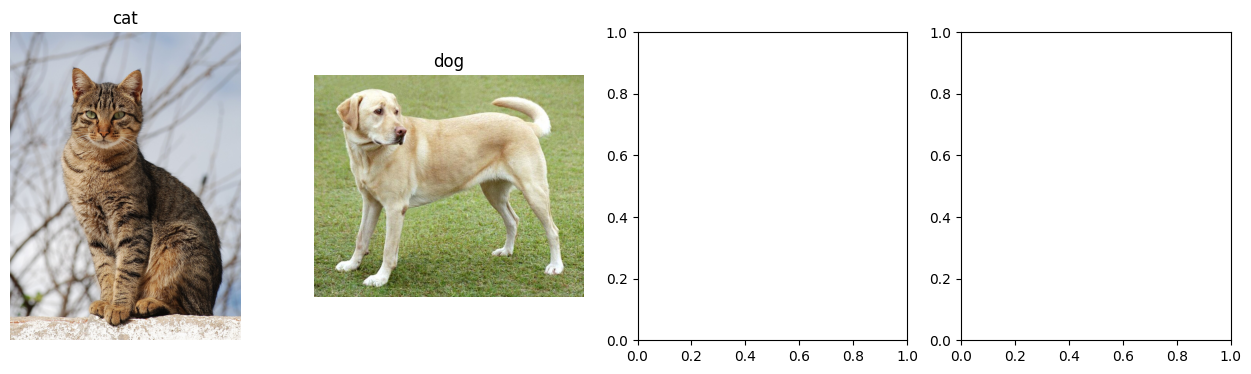

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from transformers import ViTForImageClassification, AutoImageProcessor, ViTModel

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)

def load_image(path):
    """Load a local image file and convert to RGB."""
    return Image.open(path).convert("RGB")

IMAGE_PATHS = {
    "cat":    "cat.jpg",
    "dog":    "dog.jpg",
    "parrot": "parrot.jpg",
    "car":    "car.jpg",
}

fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(16, 4))
if len(IMAGE_PATHS) == 1:
    axes = [axes]
for ax, (name, path) in zip(axes, IMAGE_PATHS.items()):
    img = load_image(path)
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("Our test images", fontsize=14)
plt.tight_layout()
plt.show()

We import **PyTorch** for tensor operations, **HuggingFace Transformers** for the pretrained ViT models, and **matplotlib/PIL** for visualization.

We load two versions of the model:
- `ViTForImageClassification` — the full model with a classification head (for predictions)
- `ViTModel` with `output_attentions=True` — the base encoder that also returns attention weights (for visualization)

The `AutoImageProcessor` handles all the preprocessing that the model expects (resize to 224×224, normalize with ImageNet statistics).

---
## 1. Loading a Pretrained ViT

We'll use **`google/vit-base-patch16-224`**, the original ViT-B/16 pretrained on ImageNet-21k and fine-tuned on ImageNet-1k.

The name tells you everything:
- `base` → 12 transformer layers, 768 hidden dim, 12 attention heads (~86M params)
- `patch16` → each patch is **16×16 pixels**
- `224` → input images are resized to **224×224**

👉 With a 224×224 image and 16×16 patches, how many patch tokens does the model get?

In [ ]:
MODEL_NAME = "google/vit-base-patch16-224"

# Feature extractor handles resizing, normalization
feature_extractor = AutoImageProcessor.from_pretrained(MODEL_NAME)

# Classification model
model_cls = ViTForImageClassification.from_pretrained(MODEL_NAME).to(device)
model_cls.eval()

# Base model with output_attentions=True (for attention maps)
model_attn = ViTModel.from_pretrained(MODEL_NAME, output_attentions=True).to(device)
model_attn.eval()

print(f"Model loaded: {MODEL_NAME}")
print(f"Number of parameters: {sum(p.numel() for p in model_cls.parameters()):,}")
print(f"Number of labels: {model_cls.config.num_labels}")
print(f"Patch size: {model_cls.config.patch_size}")
print(f"Image size: {model_cls.config.image_size}")

num_patches = ...
print(f"Number of patch tokens: {num_patches}  (+1 CLS token = {num_patches+1} total tokens)")

---
## 2. Visualizing the Patch Tokenization

Before any attention or embedding, the very first thing ViT does is slice the image into a grid of patches.
The following function visualizes the patch grid on top of an image.  
You can run it multiple times to see different random patches.

In [ ]:
import random

def preprocess_image_for_vit_viz(image, target_size=224):
    """Resizes the smallest edge to target_size and then center crops the image."""
    width, height = image.size
    if width < height:
        new_width = target_size
        new_height = int(target_size * (height / width))
    else:
        new_height = target_size
        new_width = int(target_size * (width / height))
    image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)

    left = (new_width - target_size) / 2
    top = (new_height - target_size) / 2
    right = (new_width + target_size) / 2
    bottom = (new_height + target_size) / 2
    image = image.crop((left, top, right, bottom))
    return image


def visualize_patches(image, patch_size=16, title=""):
    """Draw the patch grid on top of an image and show a random patch."""
    # Preprocess image to model input size (224x224) using smallest edge resize and center crop
    img_processed = preprocess_image_for_vit_viz(image, target_size=224)
    img_array = np.array(img_processed)

    n_patches_side = 224 // patch_size
    total_patches = n_patches_side ** 2

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Select a random patch for highlighting and display
    random_row = random.randint(0, n_patches_side - 1)
    random_col = random.randint(0, n_patches_side - 1)

    # Left: image with grid overlay and highlighted patch
    axes[0].imshow(img_array)
    for i in range(n_patches_side + 1):
        axes[0].axhline(i * patch_size, color='red', linewidth=0.5, alpha=0.7)
        axes[0].axvline(i * patch_size, color='red', linewidth=0.5, alpha=0.7)

    # Highlight the selected random patch
    rect = patches.Rectangle((random_col * patch_size, random_row * patch_size),
                             patch_size, patch_size, linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)

    axes[0].set_title(f"Patch grid ({n_patches_side}×{n_patches_side} = {total_patches} patches)\nPatch size: {patch_size}×{patch_size} px")
    axes[0].axis("off")

    # Right: show the random individual patch
    # Reshape the image array into a grid of patches
    patch_grid = img_array.reshape(n_patches_side, patch_size, n_patches_side, patch_size, 3)
    patch_grid = patch_grid.transpose(0, 2, 1, 3, 4)  # (n_patches_side, n_patches_side, patch_size, patch_size, 3)

    random_patch = patch_grid[random_row, random_col]
    token_idx = random_row * n_patches_side + random_col + 1  # +1 because token 0 is CLS

    axes[1].imshow(random_patch)
    axes[1].set_title(f"Random patch (token {token_idx})\n({random_row},{random_col})")
    axes[1].axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

# Try it on the cat image
cat_image = load_image(IMAGE_PATHS["cat"])
visualize_patches(cat_image, patch_size=16, title="ViT Patch Tokenization \u2014 Cat")

In [ ]:
dog_image = load_image(IMAGE_PATHS["dog"])  # ← change me!
visualize_patches(dog_image, patch_size=16, title="Try your own image!")

**What to observe:** The left panel shows the 14×14 grid overlaid on the 224×224 image — each red square is one "token" that the Transformer will process. The right panel extracts a single random patch: notice how small 16×16 pixels are. Each patch captures only a tiny local region, yet the Transformer must learn to combine all 196 of these fragments into a coherent understanding of the scene.

This is the fundamental difference with CNNs: instead of hierarchically building features with convolutions, ViT treats the image as a **flat sequence of patches** — just like words in a sentence.

---
## 3. Extracting Attention Maps

This is the most revealing visualization. After the image is turned into tokens, the **self-attention** mechanism lets each token attend to every other token.

We'll look at the **CLS token** (token 0) it aggregates global information for classification, so its attention pattern tells us *which patches the model considers important*.

ViT-B/16 has **12 layers × 12 heads = 144 attention maps**. We'll visualize all heads in the last layer, then aggregate them.

In [ ]:
def get_attention_maps(image, model, feature_extractor):
    """Run a forward pass and return all attention weights."""
    inputs = feature_extractor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # outputs.attentions: tuple of (batch, heads, seq_len, seq_len) per layer
    attentions = outputs.attentions  # 12 layers
    return attentions


def plot_attention_heads(image, attentions, layer=-1, patch_size=16):
    """
    Plot CLS token attention for all heads in a given layer.
    layer=-1 means the last layer.
    """
    img_resized = image.resize((224, 224))
    img_array = np.array(img_resized)

    n_patches_side = 224 // patch_size
    attn = attentions[layer][0]  # (heads, seq_len, seq_len), batch=0
    n_heads = attn.shape[0]

    # CLS token (index 0) attention over all patch tokens (index 1 onwards)
    cls_attn = attn[:, 0, 1:].cpu().numpy()  # (heads, n_patches)

    fig, axes = plt.subplots(3, 5, figsize=(18, 11))
    axes = axes.flatten()

    # First panel: original image
    axes[0].imshow(img_array)
    axes[0].set_title("Original", fontweight="bold")
    axes[0].axis("off")

    for h in range(n_heads):
        attn_map = cls_attn[h].reshape(n_patches_side, n_patches_side)
        # Normalize to [0,1]
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
        # Upscale to image size
        attn_map_upscaled = np.repeat(np.repeat(attn_map, patch_size, axis=0), patch_size, axis=1)

        axes[h + 1].imshow(img_array)
        axes[h + 1].imshow(attn_map_upscaled, alpha=0.6, cmap="inferno")
        axes[h + 1].set_title(f"Head {h+1}", fontsize=9)
        axes[h + 1].axis("off")

    layer_label = f"Layer {len(attentions) + layer + 1}" if layer < 0 else f"Layer {layer + 1}"
    plt.suptitle(f"CLS token attention — {layer_label} (all {n_heads} heads)", fontsize=13)
    plt.tight_layout()
    plt.show()


# Run on the cat
dog_attentions = get_attention_maps(dog_image, model_attn, feature_extractor)
print(f"Number of layers: {len(dog_attentions)}")
print(f"Attention shape per layer: {dog_attentions[0].shape}  (batch, heads, seq_len, seq_len)")
print(f"Sequence length: {dog_attentions[0].shape[-1]}  = 1 CLS + {dog_attentions[0].shape[-1]-1} patches")

The attention tensor has shape `(batch, heads, seq_len, seq_len)` — for ViT-B/16 that's `(1, 12, 197, 197)`. Each entry `attn[b, h, i, j]` tells us how much token `i` attends to token `j` in head `h`. Since the sequence is 1 CLS + 196 patches = 197 tokens, we get a 197×197 attention matrix per head.

To understand what the model "looks at", we extract **row 0** (the CLS token) and columns **1 to 196** (the patch tokens). This gives us a 196-dimensional vector that we can reshape into a 14×14 spatial map.

In [ ]:
# Plot all 12 attention heads in the LAST layer
plot_attention_heads(dog_image, dog_attentions, layer=-1)

**What to observe:** Each head has learned a different attention pattern. Some heads focus tightly on the main subject (e.g., the dog's face), while others attend to the background or spread attention uniformly. This **head specialization** is a key property of multi-head attention — different heads capture different types of relationships (local texture, object boundaries, global context, etc.).

No single head tells the full story; the model combines all 12 heads to form its final representation.

Attention Rollout is a method introduced by Abnar & Zuidema (2020) to visualize the attention flow in a ViT.
It works by propagating the attention across all layers to get a single 'effective attention' map from the CLS token.
The following function implements this method.




In [ ]:
def attention_rollout(attentions, patch_size=16, discard_ratio=0.9):
    """
    Attention Rollout (Abnar & Zuidema, 2020):
    Propagate attention across all layers to get a single
    'effective attention' map from the CLS token.
    """
    n_patches_side = 224 // patch_size

    # Start with identity
    rollout = None

    for attn_layer in attentions:
        # Average over heads: (batch, heads, seq, seq) → (seq, seq)
        attn = attn_layer[0].mean(dim=0).cpu().numpy()  # (seq_len, seq_len)

        # Discard low attention values to reduce noise
        flat = attn.flatten()
        threshold = np.percentile(flat, discard_ratio * 100)
        attn[attn < threshold] = 0

        # Add residual connection
        attn = attn + np.eye(attn.shape[0])
        attn = attn / attn.sum(axis=-1, keepdims=True)

        rollout = attn if rollout is None else np.matmul(attn, rollout)

    # CLS token (row 0), all patch tokens (cols 1:)
    mask = rollout[0, 1:].reshape(n_patches_side, n_patches_side)
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask


def plot_rollout_comparison(images_dict, model, feature_extractor, patch_size=16):
    """Run attention rollout on multiple images side by side."""
    n = len(images_dict)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (name, image) in enumerate(images_dict.items()):
        img_resized = image.resize((224, 224))
        img_array = np.array(img_resized)
        attentions = get_attention_maps(image, model, feature_extractor)
        mask = attention_rollout(attentions, patch_size=patch_size)
        mask_upscaled = np.repeat(np.repeat(mask, patch_size, axis=0), patch_size, axis=1)

        axes[0, col].imshow(img_array)
        axes[0, col].set_title(name, fontweight="bold")
        axes[0, col].axis("off")

        axes[1, col].imshow(img_array)
        axes[1, col].imshow(mask_upscaled, alpha=0.65, cmap="inferno")
        axes[1, col].set_title("Attention Rollout")
        axes[1, col].axis("off")

    plt.suptitle("Attention Rollout across all layers — where does ViT look?", fontsize=13)
    plt.tight_layout()
    plt.show()


# Load all 4 test images and compare
all_images = {name: load_image(path) for name, path in IMAGE_PATHS.items()}
plot_rollout_comparison(all_images, model_attn, feature_extractor)

**What to observe:** Unlike the per-head view above, rollout gives a single aggregated map that accounts for information flow across **all 12 layers**. The bright regions (high attention) typically highlight the semantically important parts of the image — the subject's body, distinctive features, etc.

The key idea behind rollout: attention in layer `L` builds on top of what was attended in layers `1..L-1`. By multiplying attention matrices across layers (with residual corrections), we trace where information actually flows from input patches to the final CLS token.

We can also visualize the attention of the CLS token across all layers.

In [ ]:
def plot_attention_across_layers(image, attentions, patch_size=16, layers_to_show=None):
    """
    Show how attention evolves across layers.
    Uses the mean over all heads.
    """
    img_resized = image.resize((224, 224))
    img_array = np.array(img_resized)
    n_patches_side = 224 // patch_size
    n_layers = len(attentions)

    if layers_to_show is None:
        # Show layers 1, 3, 6, 9, 12 (1-indexed)
        layers_to_show = [0, 2, 5, 8, 11]

    fig, axes = plt.subplots(1, len(layers_to_show) + 1, figsize=(4 * (len(layers_to_show) + 1), 4))

    axes[0].imshow(img_array)
    axes[0].set_title("Original", fontweight="bold")
    axes[0].axis("off")

    for i, layer_idx in enumerate(layers_to_show):
        attn = attentions[layer_idx][0].mean(dim=0).cpu().numpy()  # avg over heads
        cls_attn = attn[0, 1:].reshape(n_patches_side, n_patches_side)
        cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
        cls_attn_up = np.repeat(np.repeat(cls_attn, patch_size, axis=0), patch_size, axis=1)

        axes[i + 1].imshow(img_array)
        axes[i + 1].imshow(cls_attn_up, alpha=0.65, cmap="inferno")
        axes[i + 1].set_title(f"Layer {layer_idx + 1}", fontsize=10)
        axes[i + 1].axis("off")

    plt.suptitle("CLS attention (mean over heads) across layers\nEarly layers → diffuse. Later layers → focused.", fontsize=12)
    plt.tight_layout()
    plt.show()


# Watch attention evolve for the cat
plot_attention_across_layers(dog_image, dog_attentions)

You might observe that the attention seems to be focused on other parts of the image than what we would expect.
Any idea why this might be? Do all the heads focus on the same parts of the image?

---
## 4. Running Inference — Top-5 Predictions

Now let's actually use the model for what it was trained to do: **ImageNet classification**.

In [ ]:
def predict_top5(image, model, feature_extractor, plot=True):
    """Run ViT inference and return top-5 predictions with confidence bars."""
    inputs = feature_extractor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits  # (1, 1000)

    probs = torch.softmax(logits, dim=-1)[0]  # (1000,)
    top5 = torch.topk(probs, 5)

    labels = [model.config.id2label[idx.item()] for idx in top5.indices]
    scores = [p.item() for p in top5.values]

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                                  gridspec_kw={"width_ratios": [1, 2]})
        axes[0].imshow(image.resize((224, 224)))
        axes[0].axis("off")
        axes[0].set_title("Input image")

        colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(5)]
        bars = axes[1].barh(range(5), scores[::-1], color=colors[::-1])
        axes[1].set_yticks(range(5))
        axes[1].set_yticklabels([l.replace("_", " ") for l in labels[::-1]], fontsize=10)
        axes[1].set_xlabel("Confidence")
        axes[1].set_title("Top-5 Predictions")
        axes[1].set_xlim(0, 1)

        for bar, score in zip(bars, scores[::-1]):
            axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                        f"{score:.1%}", va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

    return list(zip(labels, scores))


# Run on all test images
for name, image in all_images.items():
    print(f"\n{'='*50}\n  {name.upper()}")
    results = predict_top5(image, model_cls, feature_extractor)

**What to observe:** The model outputs logits over 1,000 ImageNet classes. After applying softmax, the top-1 prediction usually has very high confidence for clear images. Notice how the model returns fine-grained labels (e.g., specific dog breeds rather than just "dog") — this is because ImageNet has many subcategories.

---
## 5. Play: Changing Patch Size

**`patch16`** isn't the only option. Let's compare different ViT variants and understand the tradeoffs:

| Model | Patch size | Tokens | More/less detail |
|---|---|---|---|
| ViT-B/32 | 32×32 | 49 | Less detail, faster |
| ViT-B/16 | 16×16 | 196 | More detail, default |

> With smaller patches you get **more tokens → more detail** but also **quadratic attention cost**. What are the implications for high-res images?

In [ ]:
# ── Load patch32 model ────────────────────────────────────────────────────────

MODEL_PATCH32 = "google/vit-base-patch32-224-in21k"  # patch32

fe_32 = AutoImageProcessor.from_pretrained(MODEL_PATCH32)
model_attn_32 = ViTModel.from_pretrained(MODEL_PATCH32, output_attentions=True).to(device)
model_attn_32.eval()

n_tokens_32 = (224 // 32) ** 2
n_tokens_16 = (224 // 16) ** 2
print(f"patch/16 → {n_tokens_16} tokens")
print(f"patch/32 → {n_tokens_32} tokens")
print(f"Attention computation: patch/16 is ~{(n_tokens_16/n_tokens_32)**2:.0f}x more expensive (O(n²))")

In [ ]:
def compare_patch_sizes(image, models_dict, patch_sizes, feature_extractors):
    """
    Side-by-side comparison of attention rollout for different patch sizes.
    models_dict: {name: model}
    """
    img_resized = np.array(image.resize((224, 224)))
    n = len(models_dict)

    fig, axes = plt.subplots(2, n + 1, figsize=(5 * (n + 1), 10))

    # Original image
    axes[0, 0].imshow(img_resized)
    axes[0, 0].set_title("Original", fontweight="bold")
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")

    for col, (name, (model, fe, ps)) in enumerate(zip(
        models_dict.keys(),
        zip(models_dict.values(), feature_extractors, patch_sizes)
    )):
        n_patches = (224 // ps) ** 2

        # Patch grid visualization
        axes[0, col + 1].imshow(img_resized)
        for k in range(224 // ps + 1):
            axes[0, col + 1].axhline(k * ps, color='red', linewidth=0.8, alpha=0.8)
            axes[0, col + 1].axvline(k * ps, color='red', linewidth=0.8, alpha=0.8)
        axes[0, col + 1].set_title(f"{name}\n{224//ps}×{224//ps} = {n_patches} tokens", fontsize=10)
        axes[0, col + 1].axis("off")

        # Attention rollout
        attentions = get_attention_maps(image, model, fe)
        mask = attention_rollout(attentions, patch_size=ps)
        mask_up = np.repeat(np.repeat(mask, ps, axis=0), ps, axis=1)

        axes[1, col + 1].imshow(img_resized)
        axes[1, col + 1].imshow(mask_up, alpha=0.65, cmap="inferno")
        axes[1, col + 1].set_title("Attention Rollout", fontsize=10)
        axes[1, col + 1].axis("off")

    plt.suptitle("Effect of patch size on tokenization and attention", fontsize=13)
    plt.tight_layout()
    plt.show()


# Compare patch/16 vs patch/32
compare_patch_sizes(
    cat_image,
    models_dict={
        "ViT-B/16 (patch=16)": model_attn,
        "ViT-B/32 (patch=32)": model_attn_32,
    },
    patch_sizes=[16, 32],
    feature_extractors=[feature_extractor, fe_32]
)

**What to observe:** With patch size 32, the grid is much coarser (7×7 = 49 tokens) — the attention map looks "blocky" and loses fine spatial detail. With patch size 16, the grid is finer (14×14 = 196 tokens) and the attention can localize more precisely on the subject.

This is the core **resolution vs. cost tradeoff**: smaller patches give better spatial precision but quadratically increase the attention computation. The next cell quantifies this cost.

In [ ]:
# ── Visualize the quadratic cost of attention as a function of image resolution ──

image_sizes = [224, 336, 448, 560, 672, 784, 896, 1024]
patch_size_16 = [(s // 16) ** 2 for s in image_sizes]
patch_size_32 = [(s // 32) ** 2 for s in image_sizes]

attn_cost_16 = [n ** 2 for n in patch_size_16]
attn_cost_32 = [n ** 2 for n in patch_size_32]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: number of tokens
axes[0].plot(image_sizes, patch_size_16, 'o-', label="patch/16", color="#e74c3c", linewidth=2)
axes[0].plot(image_sizes, patch_size_32, 's-', label="patch/32", color="#3498db", linewidth=2)
axes[0].set_xlabel("Image size (px)")
axes[0].set_ylabel("Number of tokens")
axes[0].set_title("Number of tokens vs image resolution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: attention cost (O(n²))
axes[1].plot(image_sizes, [c / 1e6 for c in attn_cost_16], 'o-', label="patch/16", color="#e74c3c", linewidth=2)
axes[1].plot(image_sizes, [c / 1e6 for c in attn_cost_32], 's-', label="patch/32", color="#3498db", linewidth=2)
axes[1].set_xlabel("Image size (px)")
axes[1].set_ylabel("Attention ops (millions, n²)")
axes[1].set_title("Quadratic attention cost — the scalability problem")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Why high-resolution ViT is expensive", fontsize=13)
plt.tight_layout()
plt.show()

print("\n📊 Key numbers:")
for size, t16, t32 in zip(image_sizes, patch_size_16, patch_size_32):
    print(f"  {size}×{size}px → patch/16: {t16:4d} tokens | patch/32: {t32:3d} tokens")

**Takeaway:** Self-attention has **O(n²)** complexity where n is the number of tokens. Doubling the image resolution quadruples the token count, which increases attention cost by **16x**. This is why vanilla ViT struggles with high-resolution images and why research has focused on efficient attention variants (Swin Transformer with windowed attention, linear attention, etc.) to scale ViTs to larger inputs.

---
## 6.  CLS Token vs Patch Tokens in Embedding Space

Let's look at the actual embeddings that come out of the ViT and verify that the CLS token really does aggregate global information.  

In [ ]:
def get_cls_embedding(image, model, feature_extractor):
    """Extract the CLS token embedding for an image."""
    inputs = feature_extractor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_embedding = outputs.last_hidden_state[0, 0]  # CLS token
    return cls_embedding.cpu().numpy()


def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# Get embeddings for all images
embeddings = {}
for name, image in all_images.items():
    embeddings[name] = get_cls_embedding(image, model_attn, feature_extractor)
    print(f"  {name}: embedding shape = {embeddings[name].shape}")

# Compute pairwise similarity matrix
names = list(embeddings.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        sim_matrix[i, j] = cosine_similarity(embeddings[n1], embeddings[n2])

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, fontsize=11)
ax.set_yticklabels(names, fontsize=11)
ax.set_title("CLS Token Cosine Similarity\n(ViT-B/16 embedding space)", fontsize=12)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center",
               color="black", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()

Which images are closest in embedding space? Does that make sense?  
At this point you should have a good intuition on the fact that the CLS token encodes global information, and the patch tokens encode local information.   
The CLS token is the global representation of the image, and the patch tokens are the local representations.  

---
## ✅ Summary — What We Learned

| Concept | Key insight |
|---|---|
| **Patch tokenization** | Images are sliced into N×N patches → flattened → treated like word tokens |
| **CLS token** | A learnable token prepended to the sequence that aggregates global info for classification |
| **Attention maps** | Different heads specialize: some attend to local features, others to the whole subject |
| **Attention rollout** | Composing attention across layers reveals which patches *really* mattered end-to-end |
| **Patch size tradeoff** | Smaller patches → more tokens → more detail but O(n²) cost |
| **Embedding space** | The CLS token encodes semantic similarity: animals cluster together |

---
## Training a ViT from scratch
We explored how a **pre-trained ViT** processes images. We will now **build one ourselves** and train it on a real dataset.
By the end of this notebook you will have:
- Implemented `PatchEmbedding`, `TransformerBlock`, and a full `ViT` in PyTorch
- Understood the **convolution trick** that makes patch embedding efficient
- Trained your model on **CIFAR-10** and compared it to a simple CNN
- Understood *why* ViT struggles on small datasets

![ViT Architecture](https://arxiv.org/html/2010.11929v2/x1.png)

We will use **CIFAR-10**: 60 000 colour images of size **32×32** across 10 classes.
To keep training fast (~3–4 min) we work on a **5 000 train / 1 000 val** subset.

---
## 7. Training a Small ViT from Scratch

So far we used a pretrained ViT. Now let's **build one from scratch** and train it on CIFAR-10 (32×32 images, 10 classes). This will help us understand each component and also reveal an important limitation of ViTs compared to CNNs.

We deliberately use a **small subset** (5,000 training images) to highlight the data efficiency gap between ViT and CNN architectures.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform)
full_val   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)

train_dataset = Subset(full_train, range(5000))
val_dataset   = Subset(full_val,   range(1000))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

# Quick visual
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])
for i, ax in enumerate(axes):
    img = images[i].permute(1,2,0).numpy() * std + mean
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 images (32×32)', y=1.05)
plt.tight_layout()
plt.show()

We divide the image into a grid of non-overlapping **P×P patches** and project each patch
into a vector of dimension **D** (the model dimension).

For a 32×32 image with P=4:
- Number of patches: N = (32/4)² = **64 patches**
- Each patch is 4×4×3 = **48 raw values**
- After projection: each patch becomes a vector of dimension **D**

The sequence fed to the Transformer is therefore of shape **(B, N+1, D)** — the +1 is for the CLS token.

### The convolution trick

Splitting then projecting patches sounds like it needs a loop, but there is a much more
elegant solution: **a single Conv2d with kernel_size=P and stride=P**.

Here is why it is equivalent:

```
Input:    (B, C, H, W)          e.g. (B, 3, 32, 32)
Conv2d(C, D, kernel_size=P, stride=P)
Output:   (B, D, H/P, W/P)      e.g. (B, 128, 8, 8)
```

Each output pixel corresponds to exactly one patch: the convolution **slides without overlap**
(stride = kernel_size), so it reads each patch exactly once and projects it linearly to D dimensions.
The 2D output grid `(H/P, W/P)` is then flattened into the sequence of N tokens.

This is **faster, GPU-friendly, and requires no explicit loop** over patches.

```
Image 32×32           Patch grid 8×8         Token sequence
┌──────────────┐       ┌───────┐              [t₀, t₁, ..., t₆₃]
│  P P│  P P│  │       │t₀│t₁│…│              each tᵢ ∈ ℝᴰ
│  P P│  P P│  │  ───► │──┼──┼─│  ──flatten►
│─────┼─────│  │       │t₈│t₉│…│
│  P P│  P P│  │       └───────┘
│  P P│  P P│  │  
└──────────────┘
  kernel=4, stride=4
```

Complete the fowwoling code to implement the patch embedding.  
Check with a random tensor that the dimensions are correct.  


In [ ]:
class PatchEmbedding(nn.Module):
    """
    Splits an image into patches using a Conv2d (the convolution trick),
    projects them to dimension `embed_dim`, prepends a CLS token,
    and adds learnable positional embeddings.
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # ── Convolution trick ──────────────────────────────────────────────
        # kernel_size = stride = patch_size  →  each kernel application
        # covers exactly one patch with NO overlap.
        # Output shape: (B, embed_dim, H/P, W/P)
        self.proj = nn.Conv2d(...)

        # Learnable CLS token — one vector shared across the batch
        self.cls_token = nn.Parameter(...)

        # Learnable positional embeddings: one per patch + one for CLS
        self.pos_embed = nn.Parameter(...)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        # Store batch size, we need it later
        B = ...

        # 1. Project patches via conv  →  (B, embed_dim, H/P, W/P)
        x = ...

        # 2. Flatten spatial dims  →  (B, num_patches, embed_dim)
        x = ...

        # 3. Prepend CLS token  →  (B, num_patches+1, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)
        x = ...

        # 4. Add positional embeddings
        x = ...
        return x

x = torch.randn(1, 3, 32, 32)
patch_embed = PatchEmbedding()
x_tokenized = patch_embed(x)
assert x_tokenized.shape == (1, 65, 128)


Before going further, let's make sure we understand what the patch embedding actually produces.

**Q: For a 32×32 image with patch_size=4 and embed_dim=128, what shape do you expect out of `PatchEmbedding`?**

Think about it, then run the cell below to check.

In [ ]:
patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=128)

x = torch.zeros(2, 3, 32, 32)   # batch of 2 images
x_tokenized   = patch_embed(x)

print('Input  shape:', x.shape)   # (B, C, H, W)
print('Output shape:', x_tokenized.shape)     # (B, ?, ?)
print()
print(f'  Number of patches : (32/4)² = {(32//4)**2}')
print(f'  + CLS token       : 1')
print(f'  = Sequence length : {(32//4)**2 + 1}')
print(f'  Embedding dim     : 128')
print()
print('  ► Each image becomes a sequence of 65 tokens of dimension 128.')
print('    Compare to NLP: a sentence of 65 words — the Transformer sees no difference!')

# Visualise the patch grid
sample_img, _ = next(iter(train_loader))
sample_img = sample_img[0]  # (3, 32, 32)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])
img_np = sample_img.permute(1,2,0).numpy() * std + mean
img_np = np.clip(img_np, 0, 1)

axes[0].imshow(img_np)
axes[0].set_title('Original image (32×32)', fontsize=12)
# Draw patch grid
# for i in range(0, 32, 4):
#     axes[0].axhline(i - 0.5, color='red', linewidth=0.8)
#     axes[0].axvline(i - 0.5, color='red', linewidth=0.8)
# axes[0].axis('off')

axes[1].imshow(img_np.reshape(8, 4, 8, 4, 3).transpose(0,2,1,3,4).reshape(8,8,16,3)[:,:,:3,:].mean(axis=2))
patch_grid = img_np.reshape(8, 4, 8, 4, 3).transpose(0,2,1,3,4).reshape(64,4,4,3)
grid_img = patch_grid.reshape(8, 8, 4, 4, 3).transpose(0,2,1,3,4).reshape(32,32,3)
axes[1].imshow(grid_img)
for i in range(0, 32, 4):
    axes[1].axhline(i - 0.5, color='red', linewidth=1.5)
    axes[1].axvline(i - 0.5, color='red', linewidth=1.5)
axes[1].set_title('Patch grid  →  8×8 = 64 tokens', fontsize=12)
axes[1].axis('off')

plt.suptitle('The image is split into 64 non-overlapping 4×4 patches\n'
             'Each patch → one token of dimension 128 (via the Conv2d trick)', fontsize=11)
plt.tight_layout()
plt.show()

The output shape `(2, 65, 128)` confirms:
- **Batch size 2** — we passed 2 images
- **65 tokens** = 64 patches + 1 CLS token — exactly `(32/4)² + 1`
- **128 dimensions** — the embedding size

From this point on, the Transformer has no idea it's looking at an image. It just sees a sequence of 65 vectors — exactly the same format as a text Transformer processing 65 word embeddings.

### Transformer Block

The Transformer block is the main building block of the ViT.

It is a standard Transformer encoder block with a small difference: each block applies two sub-layers with **residual connections** (Pre-LN variant, more stable to train):

```
x  ──►  LayerNorm  ──►  MHSA  ──►  + x  ──►  LayerNorm  ──►  MLP  ──►  + x
            (skip connection)                     (skip connection)
```

We will use **`nn.MultiheadAttention`** for the attention part.
Complete the following code to implement the Transformer block.  
You can look at the schema in the ViT image above to understand the different steps.

In [ ]:
class TransformerBlock(nn.Module):
    """
    One Transformer encoder block (Pre-LN):
        x = x + MHSA(LayerNorm(x))
        x = x + MLP(LayerNorm(x))
    """
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)

        # MLP block: Linear → GELU → Dropout → Linear → Dropout
        # The hidden dimension is embed_dim * mlp_ratio (typically 4×)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            ...
        )

    def forward(self, x):
        # --- Attention sub-layer (with residual) ---
        normed = ...
        attn_out, _ = #  (self-attention, look at the doc for the parameters and output)
        x = ...

        # --- MLP sub-layer (with residual) ---
        x = ...
        return x

### Full ViT
We now just need to assemble **PatchEmbedding + L × TransformerBlock + classification head**.
The head operates on the **CLS token** (index 0) of the final layer's output.  
Complete the following code to implement the full ViT.

In [ ]:
class ViT(nn.Module):
    def __init__(
        self,
        img_size    = 32,
        patch_size  = 4,
        in_channels = 3,
        num_classes = 10,
        embed_dim   = 128,
        depth       = 6,       # number of Transformer blocks
        num_heads   = 4,
        mlp_ratio   = 4,
        dropout     = 0.1,
    ):
        super().__init__()

        self.patch_embed = ...
        self.dropout     = nn.Dropout(dropout)

        self.blocks = nn.Sequential(...)

        self.norm = nn.LayerNorm(embed_dim)

        # Classification head: take the CLS token, project to num_classes
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = ...
        x = ...
        x = ...        # (B, N+1, D)  after L blocks
        x = ...
        cls = ...             # CLS token  →  (B, D)
        return ...     # (B, num_classes)


# ── Sanity check ──────────────────────────────────────────────────────────────
vit = ViT().to(device)
x = torch.zeros(4, 3, 32, 32).to(device)
logits = vit(x)
print('Input  shape:', x.shape)
print('Output shape:', logits.shape, '  ← one logit per class')

total_params = sum(p.numel() for p in vit.parameters())
print(f'\nTotal parameters: {total_params:,}  (~{total_params/1e6:.1f}M)')

### Training
We will train for **15 epochs** with:
- **AdamW** optimizer (weight decay acts as regularisation)
- **CosineAnnealingLR** scheduler (smooth learning rate decay)
- **CrossEntropyLoss**

Complete the following code to implement the training and evaluation loops.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ...
        loss    = ...
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = ...
        loss    = ...
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

The training loop follows the standard PyTorch pattern: forward pass, compute loss, backward pass, optimizer step. The `@torch.no_grad()` decorator on `evaluate` disables gradient computation during validation, saving memory and time.

We track both **loss** (how wrong the predictions are) and **accuracy** (how often the top prediction is correct) for both train and validation sets, which will let us detect overfitting.

Now let's train the model!

In [ ]:
NUM_EPOCHS = 15

vit       = ...
criterion = ...
optimizer = optim.AdamW(vit.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

vit_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Training ViT for {NUM_EPOCHS} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7}')
print('-' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = ...
    va_loss, va_acc = ...
    scheduler.step()

    vit_history['train_loss'].append(tr_loss)
    vit_history['val_loss'].append(va_loss)
    vit_history['train_acc'].append(tr_acc)
    vit_history['val_acc'].append(va_acc)

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.1%} | {va_loss:>8.4f} | {va_acc:>6.1%}')

print(f'\nFinal ViT val accuracy: {vit_history["val_acc"][-1]:.1%}')

What do you think of the ViT's performance?
Let's train a simple **ConvNet of similar size** on the same data and see how it compares.

This CNN uses roughly 4 times less parameters, but encodes two **inductive biases** that ViT does not have:
- **Translation equivariance** — a cat in the top-left activates the same filters as a cat bottom-right
- **Locality** — a pixel is compared only to its neighbours, not to every other pixel

These priors are very useful when data is scarce.

Complete the following code to implement the SimpleCNN with:

- 3 convolution blocks (VGG style):
    - block 1: 32 filters of size 3, padding 1
    - block 2: 64 filters of size 3, padding 1
    - block 3: 128 filters of size 3, padding 1
- 2 max-pooling layers
- 2 dropout layers (0.1)
- 1 adaptive average pooling layer
- 1 linear layer
- 1 softmax layer


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ...
        )
        self.head = nn.Sequential(
            ...
        )

    def forward(self, x):
        return self.head(self.features(x))


cnn = SimpleCNN().to(device)
total_cnn = sum(p.numel() for p in cnn.parameters())
total_vit = sum(p.numel() for p in vit.parameters())
print(f'CNN params: {total_cnn:,}  (~{total_cnn/1e6:.1f}M)')
print(f'ViT params: {total_vit:,}  (~{total_vit/1e6:.1f}M)')

In [ ]:
cnn_optimizer = optim.AdamW(cnn.parameters(), lr=3e-4, weight_decay=0.05)
cnn_scheduler = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=NUM_EPOCHS)

cnn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Training CNN for {NUM_EPOCHS} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7}')
print('-' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = ...
    va_loss, va_acc = ...
    cnn_scheduler.step()

    cnn_history['train_loss'].append(tr_loss)
    cnn_history['val_loss'].append(va_loss)
    cnn_history['train_acc'].append(tr_acc)
    cnn_history['val_acc'].append(va_acc)

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.1%} | {va_loss:>8.4f} | {va_acc:>6.1%}')

print(f'\nFinal CNN val accuracy: {cnn_history["val_acc"][-1]:.1%}')

Now let's compare both models side by side. We plot the loss and accuracy curves to see how each architecture learned over the 15 epochs.

We also show per-image predictions from both models to get a qualitative sense of where each one succeeds and fails.

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, vit_history['train_loss'], 'b--', label='ViT train')
axes[0].plot(epochs, vit_history['val_loss'],   'b-',  label='ViT val',   linewidth=2)
axes[0].plot(epochs, cnn_history['train_loss'], 'r--', label='CNN train')
axes[0].plot(epochs, cnn_history['val_loss'],   'r-',  label='CNN val',   linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a*100 for a in vit_history['train_acc']], 'b--', label='ViT train')
axes[1].plot(epochs, [a*100 for a in vit_history['val_acc']],   'b-',  label='ViT val',   linewidth=2)
axes[1].plot(epochs, [a*100 for a in cnn_history['train_acc']], 'r--', label='CNN train')
axes[1].plot(epochs, [a*100 for a in cnn_history['val_acc']],   'r-',  label='CNN val',   linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('ViT vs CNN — trained from scratch on 5 000 CIFAR-10 images', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n{"Model":>6} | {"Val Accuracy":>12}')
print('-' * 22)
print(f'{"ViT":>6} | {vit_history["val_acc"][-1]:>11.1%}')
print(f'{"CNN":>6} | {cnn_history["val_acc"][-1]:>11.1%}')

# Visual predictions: ViT vs CNN side by side
test_images, test_labels = next(iter(val_loader))
test_images_dev = test_images[:8].to(device)

with torch.no_grad():
    vit_preds = vit(test_images_dev).argmax(1).cpu()
    cnn_preds = cnn(test_images_dev).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])

for i in range(8):
    img = test_images[i].permute(1,2,0).numpy() * std + mean
    img = np.clip(img, 0, 1)
    true_label = CLASSES[test_labels[i]]

    for row, (preds, name) in enumerate([(vit_preds, 'ViT'), (cnn_preds, 'CNN')]):
        axes[row, i].imshow(img)
        pred_label = CLASSES[preds[i]]
        correct = pred_label == true_label
        color = 'green' if correct else 'red'
        axes[row, i].set_title(f'{name}: {pred_label}', fontsize=8,
                               color=color, fontweight='bold')
        if i == 0:
            axes[row, i].set_ylabel(name, fontsize=10)
        axes[row, i].axis('off')

plt.suptitle(f'Predictions (green=correct, red=wrong) — True labels on x-axis', fontsize=11)
# Add true labels
for i in range(8):
    axes[1, i].set_xlabel(CLASSES[test_labels[i]], fontsize=8)
plt.tight_layout()
plt.show()

Why Does ViT Underperform the CNN Here?

You likely observed the CNN winning by a significant margin. This is **expected and instructive**.

### Inductive biases

| Property | CNN | ViT |
|---|---|---|
| **Translation equivariance** | ✅ Built-in | ❌ Must learn from data |
| **Locality** | ✅ Kernels operate locally | ❌ Attends everywhere from layer 1 |
| **Data needed to learn these** | Small | Large |

A CNN says *"I know that nearby pixels are related and that patterns repeat across space."*  
A ViT says *"I will figure out all spatial relationships from the data."*  
That requires **a lot** more data.

### The data hunger of ViT

The original ViT paper showed that ViT only **outperforms CNNs** when pre-trained on very large datasets (ImageNet-21k, JFT-300M).  
On small data, a ResNet easily wins.

This is exactly why modern ViTs almost always start from **pre-trained weights** — the self-supervised or supervised pre-training on huge corpora compensates for the lack of inductive biases.

### What would close the gap?
- **Pre-training** on a large dataset (the real fix)
- **Data augmentation** (RandAugment, Mixup, CutMix)
- **More data** — with the full CIFAR-10 (50k images) the gap shrinks considerably
- **DeiT training tricks** (knowledge distillation from a CNN teacher)

---
### ✅ Summary

| What we built | Key insight |
|---|---|
| **PatchEmbedding** | A Conv2d with kernel=stride=P elegantly replaces explicit patch slicing |
| **Token sequence** | A 32×32 image → 65 tokens of dim 128 — indistinguishable from a text sequence |
| **TransformerBlock** | Pre-LN, MHSA + MLP with residuals; `nn.MultiheadAttention` handles the heavy lifting |
| **CLS token** | Acts as a global summary — the classification head reads only this token |
| **ViT vs CNN** | ViT has no inductive bias → needs much more data or pre-training to shine |

---
### 🚀 Up Next
How did researchers solve the data hunger problem without collecting billions of images?  
→ **Self-supervised learning**: DINO, MAE, and how ViTs learn structure on their own.